# Case no. 1 - Blocked air line
1. Træningsdata (Baseline)
Nøglerne Set1_1, Set1_2 og Set1_3 svarer til de datasæt, der er indsamlet under normale driftsbetingelser (uden fejl). I din fil er disse navngivet som Set1_x. Det er disse data, I skal bruge til at "lære" jeres modeller, hvordan systemet ser ud, når alt kører, som det skal.

2. Fejldata (Fault Case 1: Air line blockage)
Nøglerne EvoFault1_1, EvoFault1_2 og EvoFault1_3 er jeres testdata, hvor fejlen er til stede.


Fault Case 1 er specifikt en gradvis blokering af lufttilførslen.


EvoFault1_1 (Changing conditions): Dette sæt er det mest komplekse, da både luft- og vandgennemstrømningen varieres, mens fejlen udvikler sig. Det er her, CVA-modellen for alvor skal vise sit værd over for f.eks. PCA.


EvoFault1_2 og 1_3 (Steady-state): Her holdes flow-raterne konstante, mens ventilen lukkes. Det er ofte her, det er lettest at se fejlen første gang, da der ikke er "støj" fra ændrede setpunkter 

In [ ]:
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt

# 1. Indlæs filen
mat_data = scipy.io.loadmat('CVACaseStudy/FaultyCase1.mat')

# 2. Definer kolonnenavne (fra artiklens Table 1)
column_names = [
    "Air_Delivery_P", "P_Bottom_Riser", "P_Top_Riser", "P_Top_Separator", 
    "P_3Phase_Separator", "Diff_P_Riser", "Diff_P_VC404", "Air_In_Flow", 
    "Water_In_Flow", "Flow_Top_Riser", "Level_Top_Sep", "Flow_Top_Sep_Out", 
    "Density_Top_Riser", "Density_Top_Sep_Out", "Density_Water_In", 
    "Temp_Top_Riser", "Temp_Top_Sep_Out", "Temp_Water_In", "Level_3Phase_Sep", 
    "Pos_VC501", "Pos_VC302", "Pos_VC101", "Pump_Current_PO1", "P_Mixture_2in"
]

# 3. Opret DataFrames (vi bruger kun de første 23 kolonner jf. artiklen)
df_normal = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names[:23])

print(f"Normal data klar: {df_normal.shape}")

Normal data klar: (5811, 23)


Import af fault

In [27]:
import pandas as pd

# 1. Det normale datasæt (Set1_1) har alle 24 sensorer
# Vi tager de første 23 kolonner som foreslået i artiklen
df_normal = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names[:23])

# 2. EvoFault1_1 har kun 1 kolonne - det er sandsynligvis ventil-åbningen (Fault Evolution)
# Vi giver den et sigende navn i stedet for de 23 sensor-navne
df_fault_signal = pd.DataFrame(mat_data['EvoFault1_1'], columns=["Valve_Opening_Percent"])

print(f"Normal data shape: {df_normal.shape}")  # Output: (5811, 23)
print(f"Fault signal shape: {df_fault_signal.shape}") # Output: (5811, 1)

# Tjek størrelsen på alle de andre 'EvoFault' nøgler
for key in ['EvoFault1_1', 'EvoFault1_2', 'EvoFault1_3']:
    print(f"{key} shape: {mat_data[key].shape}")

Normal data shape: (5811, 23)
Fault signal shape: (5811, 1)
EvoFault1_1 shape: (5811, 1)
EvoFault1_2 shape: (4467, 1)
EvoFault1_3 shape: (4321, 1)


Visualisering af fault

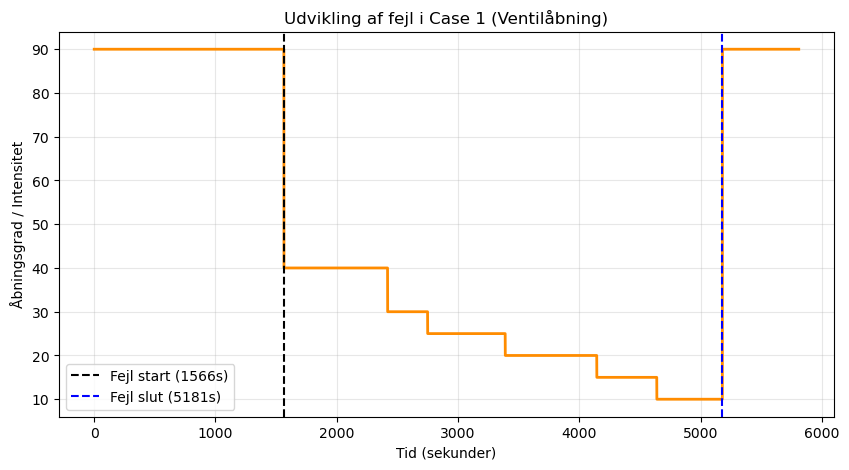

In [29]:
import matplotlib.pyplot as plt

# Vi antager nu, at EvoFault1_1 indeholder selve fejlsignalet (ventil-åbning)
plt.figure(figsize=(10, 5))
plt.plot(df_fault_signal["Valve_Opening_Percent"], color='darkorange', linewidth=2)

# Markér start og slut jf. artiklens Tabel 4 for datasæt 1.1
plt.axvline(x=1566, color='black', linestyle='--', label='Fejl start (1566s)')
plt.axvline(x=5181, color='blue', linestyle='--', label='Fejl slut (5181s)') 
plt.title("Udvikling af fejl i Case 1 (Ventilåbning)")
plt.xlabel("Tid (sekunder)")
plt.ylabel("Åbningsgrad / Intensitet")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Jeg vælger at fokusere på set1_1 og evoFault1_1. 

Der er 24 variabler og 5811 rækker i det normale dataset, og samme antal observationer, men kun 1 variabel i fault. 

In [30]:
import scipy.io

# Indlæs filen igen for en sikkerheds skyld
mat_data = scipy.io.loadmat(r'C:\Users\Dyhrh\OneDrive\Skrivebord\Fault detection\CVACaseStudy\FaultyCase1.mat')

print("--- Oversigt over variabler i filen ---")
for key in mat_data.keys():
    # Vi springer de indbyggede metadata over (__header__ osv.)
    if not key.startswith('__'):
        shape = mat_data[key].shape
        print(f"Variabel: {key:15} | Størrelse: {shape}")

--- Oversigt over variabler i filen ---
Variabel: Set1_1          | Størrelse: (5811, 24)
Variabel: Set1_2          | Størrelse: (4467, 24)
Variabel: Set1_3          | Størrelse: (4321, 24)
Variabel: EvoFault1_1     | Størrelse: (5811, 1)
Variabel: EvoFault1_2     | Størrelse: (4467, 1)
Variabel: EvoFault1_3     | Størrelse: (4321, 1)
